<a href="https://colab.research.google.com/github/DivishaTapadiya/object_classifier/blob/main/object_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


IMPORTING MODULES

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os
from collections import defaultdict

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.11.0+cu128


SETIING THE DATASET PATH

In [ ]:
dataset_path = '/content/drive/MyDrive/CEAM_project/dataset'

print("Checking dataset...")
print("-" * 40)

total = 0
for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg'))]
        print(f"{class_name}: {len(images)} images")
        total += len(images)

print("-" * 40)
print(f"Total images: {total}")

Checking dataset...
----------------------------------------
apple: 15 images
guava: 15 images
leaf: 15 images
mango: 15 images
----------------------------------------
Total images: 60


IMAGE TRANFORMS

In [ ]:
# Training transforms — heavy augmentation because we only have 15 images per class
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),          # resize all images to same size
    transforms.RandomHorizontalFlip(p=0.5), # 50% chance to flip left-right
    transforms.RandomVerticalFlip(p=0.2),   # 20% chance to flip upside down
    transforms.RandomRotation(degrees=30),  # rotate randomly up to 30 degrees
    transforms.ColorJitter(                 # randomly change colors
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1),
    transforms.RandomGrayscale(p=0.1),     # occasionally convert to grayscale
    transforms.ToTensor(),                  # convert pixels to numbers 0-1
    transforms.Normalize(                   # normalize using ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

# Validation transforms — NO augmentation, just resize and normalize
val_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

print("Transforms defined!")
print(f"Training transforms: {len(train_transforms.transforms)} steps")
print(f"Validation transforms: {len(val_transforms.transforms)} steps")

Transforms defined!
Training transforms: 8 steps
Validation transforms: 3 steps


LOAD AND SPLIT CELL DATA

In [ ]:
# Load full dataset with training transforms first
full_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transforms
)

# Print class information
print(f"Classes found: {full_dataset.classes}")
print(f"Class indices: {full_dataset.class_to_idx}")
print(f"Total images: {len(full_dataset)}")

# Split: 80% train, 20% validation
# With 60 images: 48 train, 12 validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

torch.manual_seed(42)  # for reproducibility
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply validation transforms to validation set
val_dataset.dataset.transform = val_transforms

print(f"\nTraining images: {train_size}")
print(f"Validation images: {val_size}")

Classes found: ['apple', 'guava', 'leaf', 'mango']
Class indices: {'apple': 0, 'guava': 1, 'leaf': 2, 'mango': 3}
Total images: 60

Training images: 48
Validation images: 12


CREATE DATA LOADERS

In [ ]:
BATCH_SIZE = 8  # small batch size because we have very few images

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,       # shuffle every epoch so model doesn't memorize order
    num_workers=2       # parallel loading for speed
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,      # no need to shuffle validation
    num_workers=2
)

print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches per epoch: {len(val_loader)}")

Batch size: 8
Training batches per epoch: 6
Validation batches per epoch: 2


VISUALISING DATA SET

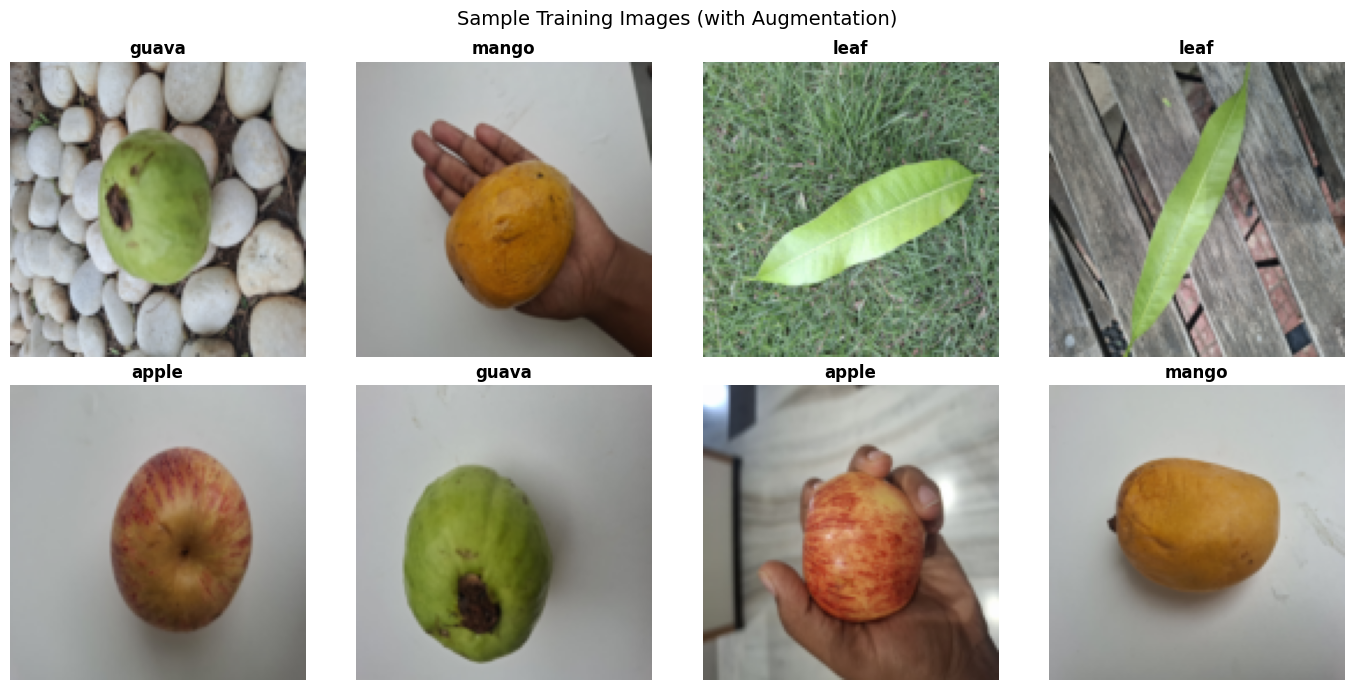

Sample images saved!


In [ ]:
def imshow(img):
    # undo normalization so image looks normal to human eyes
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

# Get one batch
images, labels = next(iter(train_loader))
classes = full_dataset.classes

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(min(8, len(images))):
    axes[i].imshow(imshow(images[i]))
    axes[i].set_title(f"{classes[labels[i]]}", fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Sample Training Images (with Augmentation)", fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample images saved!")

BUILDING THE NEURAL NETWORK

In [ ]:
class FruitClassifier(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.5):
        super(FruitClassifier, self).__init__()

        # CONVOLUTIONAL LAYERS — extract visual features from images
        self.features = nn.Sequential(

            # Block 1: edges, colors
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            # 3 = RGB channels in, 32 = number of filters, 3x3 kernel
            nn.BatchNorm2d(32),
            # normalizes outputs — keeps values in good range for training
            nn.ReLU(inplace=True),
            # activation: converts negatives to 0, keeps positives
            nn.MaxPool2d(2, 2),
            # shrinks image from 128x128 to 64x64
            nn.Dropout2d(0.1),
            # randomly zeros out 10% of feature maps

            # Block 2: learns complex features — shapes, textures
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # shrinks from 64x64 to 32x32
            nn.Dropout2d(0.2),

            # Block 3: learns high level features — fruit shapes
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # shrinks from 32x32 to 16x16
            nn.Dropout2d(0.2),
        )

        # FULLY CONNECTED LAYERS — combines features to make prediction
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # flattens 128 x 16 x 16 = 32768 values into one long list
            nn.Linear(128 * 16 * 16, 256),
            # fully connected: every feature connects to 256 neurons
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            # randomly drops neurons to prevent overfitting
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_classes)
            # final layer: 4 outputs = 4 classes (apple/guava/leaf/mango)
        )

    def forward(self, x):
        x = self.features(x)      # extract features
        x = self.classifier(x)    # classify
        return x

# Create baseline model
model = FruitClassifier(num_classes=4, dropout_rate=0.5).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model created successfully!")
print(f"Total parameters: {total_params:,}")
print(f"\nModel architecture:")
print(model)

Model created successfully!
Total parameters: 8,499,268

Model architecture:
FruitClassifier(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.1, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.2, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, paddi

TRAINING FUNCTION

In [ ]:
def train_model(model, train_loader, val_loader,
                criterion, optimizer, num_epochs, experiment_name):

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    print(f"\n{'='*60}")
    print(f"  Experiment: {experiment_name}")
    print(f"{'='*60}")

    for epoch in range(num_epochs):

        # ── TRAINING PHASE ──────────────────────────────
        model.train()
        # tells model we are training
        # this enables dropout and batchnorm training behavior

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            # 1. Clear gradients from previous step
            optimizer.zero_grad()

            # 2. Forward pass: get predictions
            outputs = model(images)

            # 3. Calculate how wrong we are
            loss = criterion(outputs, labels)

            # 4. Backpropagation: calculate gradients
            loss.backward()

            # 5. Update weights using gradients
            optimizer.step()

            # Track stats
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = 100 * train_correct / train_total

        # ── VALIDATION PHASE ────────────────────────────
        model.eval()
        # tells model we are evaluating
        # this disables dropout so all neurons are active

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            # no_grad means don't track gradients
            # saves memory and speeds up validation
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = 100 * val_correct / val_total

        # Save history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_acc'].append(avg_val_acc)

        # Print every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:3d}/{num_epochs}] "
                  f"Train Loss: {avg_train_loss:.4f} | "
                  f"Train Acc: {avg_train_acc:.1f}% | "
                  f"Val Loss: {avg_val_loss:.4f} | "
                  f"Val Acc: {avg_val_acc:.1f}%")

    print(f"\nFinal Results:")
    print(f"  Best Train Acc: {max(history['train_acc']):.1f}%")
    print(f"  Best Val Acc:   {max(history['val_acc']):.1f}%")

    return history


PLOTTING FUNCTION

In [ ]:
def plot_experiment(history, experiment_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    # Loss plot
    ax1.plot(epochs, history['train_loss'], 'b-o',
             label='Train Loss', linewidth=2, markersize=4)
    ax1.plot(epochs, history['val_loss'], 'r-o',
             label='Val Loss', linewidth=2, markersize=4)
    ax1.set_title(f'{experiment_name}\nLoss Curve', fontsize=13)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy plot
    ax2.plot(epochs, history['train_acc'], 'b-o',
             label='Train Accuracy', linewidth=2, markersize=4)
    ax2.plot(epochs, history['val_acc'], 'r-o',
             label='Val Accuracy', linewidth=2, markersize=4)
    ax2.set_title(f'{experiment_name}\nAccuracy Curve', fontsize=13)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 105])

    plt.tight_layout()
    filename = f"{experiment_name.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved as {filename}")

RUNNING EXPERIMENTS


EXPERIMENT 1: Baseline

  Experiment: Exp1 Baseline (Adam lr=0.001)
Epoch [  1/40] Train Loss: 3.5758 | Train Acc: 22.9% | Val Loss: 1.6488 | Val Acc: 16.7%
Epoch [  5/40] Train Loss: 1.7317 | Train Acc: 41.7% | Val Loss: 1.2306 | Val Acc: 41.7%
Epoch [ 10/40] Train Loss: 1.0819 | Train Acc: 66.7% | Val Loss: 1.2449 | Val Acc: 58.3%
Epoch [ 15/40] Train Loss: 0.6311 | Train Acc: 70.8% | Val Loss: 0.3741 | Val Acc: 83.3%
Epoch [ 20/40] Train Loss: 0.3478 | Train Acc: 87.5% | Val Loss: 0.2384 | Val Acc: 91.7%
Epoch [ 25/40] Train Loss: 0.1584 | Train Acc: 93.8% | Val Loss: 0.2162 | Val Acc: 83.3%
Epoch [ 30/40] Train Loss: 0.1866 | Train Acc: 89.6% | Val Loss: 0.1790 | Val Acc: 91.7%
Epoch [ 35/40] Train Loss: 0.3614 | Train Acc: 87.5% | Val Loss: 0.2241 | Val Acc: 91.7%
Epoch [ 40/40] Train Loss: 0.3362 | Train Acc: 83.3% | Val Loss: 0.1983 | Val Acc: 91.7%

Final Results:
  Best Train Acc: 97.9%
  Best Val Acc:   100.0%


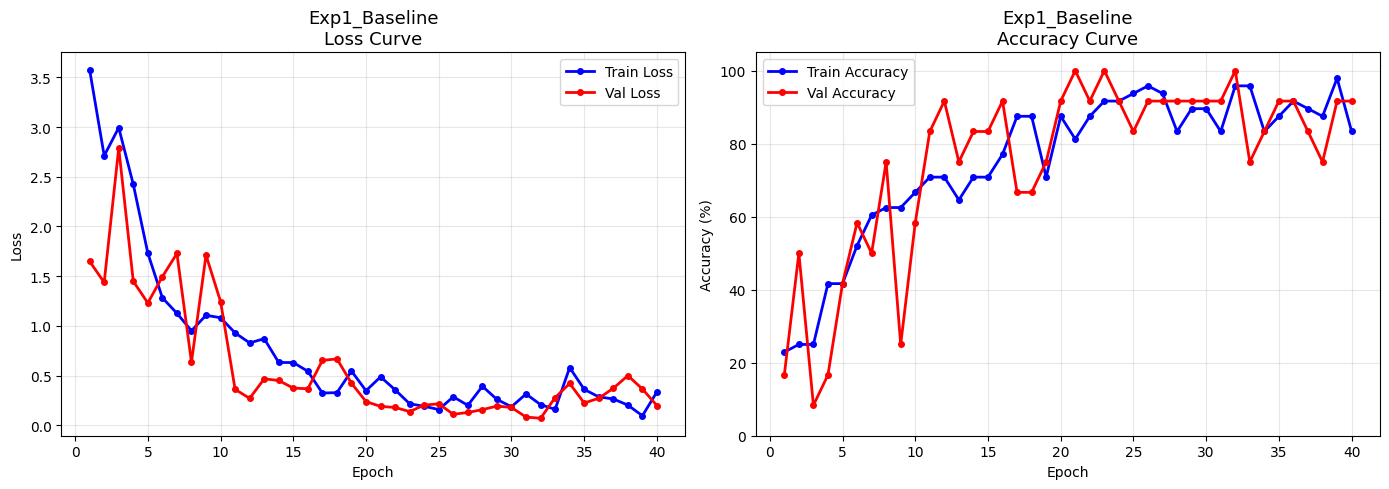

Plot saved as Exp1_Baseline.png

EXPERIMENT 2: High Learning Rate (Unstable)

  Experiment: Exp2 High LR (lr=0.1) - Unstable
Epoch [  1/40] Train Loss: 5054.7276 | Train Acc: 29.2% | Val Loss: 9972.6426 | Val Acc: 33.3%
Epoch [  5/40] Train Loss: 5.1606 | Train Acc: 37.5% | Val Loss: 1.7800 | Val Acc: 8.3%
Epoch [ 10/40] Train Loss: 1.3733 | Train Acc: 31.2% | Val Loss: 1.4496 | Val Acc: 16.7%
Epoch [ 15/40] Train Loss: 1.3790 | Train Acc: 25.0% | Val Loss: 1.4484 | Val Acc: 16.7%
Epoch [ 20/40] Train Loss: 1.3196 | Train Acc: 35.4% | Val Loss: 1.5788 | Val Acc: 0.0%
Epoch [ 25/40] Train Loss: 1.4326 | Train Acc: 29.2% | Val Loss: 1.5357 | Val Acc: 0.0%
Epoch [ 30/40] Train Loss: 1.3652 | Train Acc: 31.2% | Val Loss: 1.5764 | Val Acc: 0.0%
Epoch [ 35/40] Train Loss: 1.3718 | Train Acc: 31.2% | Val Loss: 1.5725 | Val Acc: 0.0%
Epoch [ 40/40] Train Loss: 1.3725 | Train Acc: 31.2% | Val Loss: 1.5230 | Val Acc: 0.0%

Final Results:
  Best Train Acc: 45.8%
  Best Val Acc:   33.3%


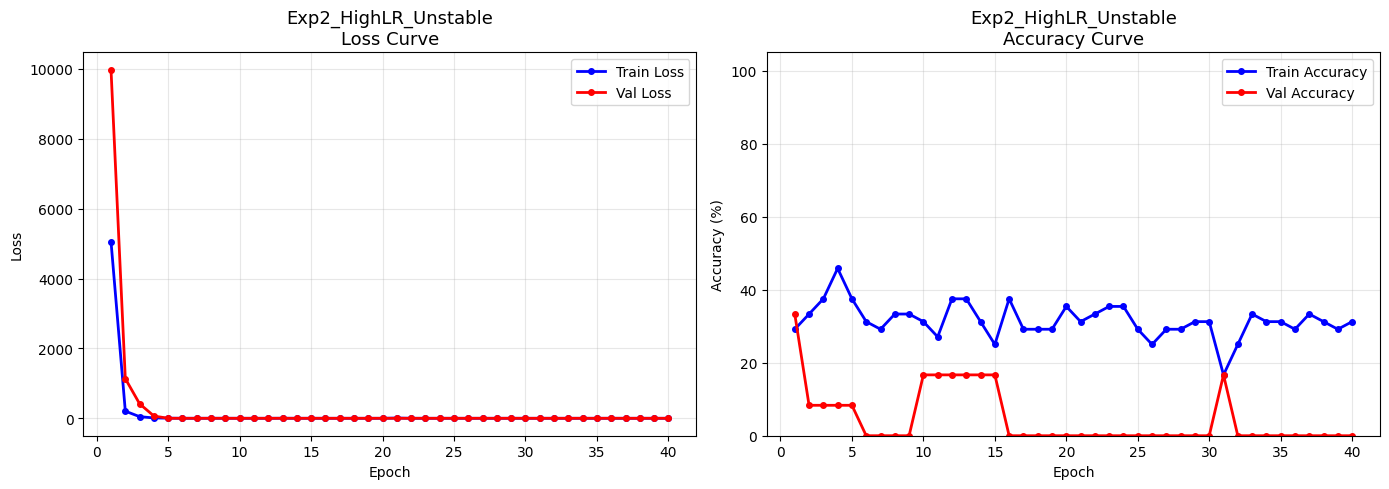

Plot saved as Exp2_HighLR_Unstable.png

EXPERIMENT 3: No Dropout (Overfitting)

  Experiment: Exp3 No Dropout - Overfitting
Epoch [  1/40] Train Loss: 6.0444 | Train Acc: 20.8% | Val Loss: 1.7266 | Val Acc: 0.0%
Epoch [  5/40] Train Loss: 0.5430 | Train Acc: 87.5% | Val Loss: 0.4730 | Val Acc: 83.3%
Epoch [ 10/40] Train Loss: 0.4077 | Train Acc: 89.6% | Val Loss: 0.1430 | Val Acc: 100.0%
Epoch [ 15/40] Train Loss: 0.1374 | Train Acc: 93.8% | Val Loss: 0.2581 | Val Acc: 91.7%
Epoch [ 20/40] Train Loss: 0.0717 | Train Acc: 100.0% | Val Loss: 0.9605 | Val Acc: 75.0%
Epoch [ 25/40] Train Loss: 0.0225 | Train Acc: 100.0% | Val Loss: 0.4207 | Val Acc: 83.3%
Epoch [ 30/40] Train Loss: 0.0250 | Train Acc: 100.0% | Val Loss: 1.2115 | Val Acc: 58.3%
Epoch [ 35/40] Train Loss: 0.0308 | Train Acc: 100.0% | Val Loss: 2.3352 | Val Acc: 25.0%
Epoch [ 40/40] Train Loss: 0.0034 | Train Acc: 100.0% | Val Loss: 0.4997 | Val Acc: 66.7%

Final Results:
  Best Train Acc: 100.0%
  Best Val Acc:   100.0%


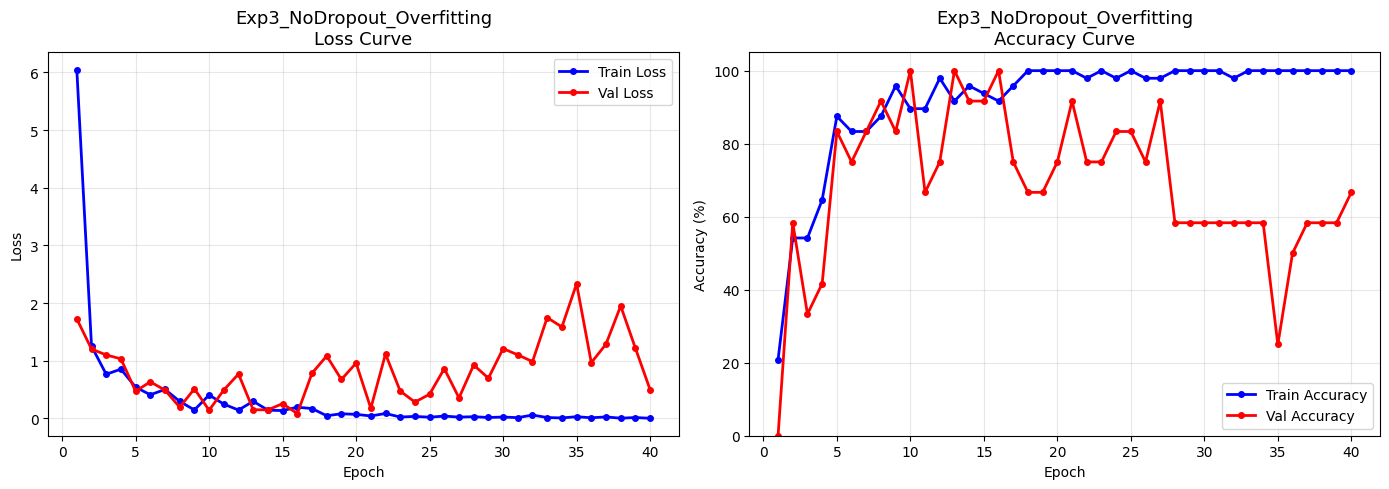

Plot saved as Exp3_NoDropout_Overfitting.png

EXPERIMENT 4: SGD Optimizer

  Experiment: Exp4 SGD Optimizer
Epoch [  1/40] Train Loss: 1.4009 | Train Acc: 33.3% | Val Loss: 1.4684 | Val Acc: 16.7%
Epoch [  5/40] Train Loss: 1.2635 | Train Acc: 35.4% | Val Loss: 1.4017 | Val Acc: 25.0%
Epoch [ 10/40] Train Loss: 1.4795 | Train Acc: 47.9% | Val Loss: 1.6033 | Val Acc: 16.7%
Epoch [ 15/40] Train Loss: 1.0810 | Train Acc: 45.8% | Val Loss: 1.0844 | Val Acc: 58.3%
Epoch [ 20/40] Train Loss: 1.4643 | Train Acc: 33.3% | Val Loss: 1.3722 | Val Acc: 41.7%
Epoch [ 25/40] Train Loss: 1.4321 | Train Acc: 50.0% | Val Loss: 2.1754 | Val Acc: 16.7%
Epoch [ 30/40] Train Loss: 0.9771 | Train Acc: 47.9% | Val Loss: 1.3587 | Val Acc: 0.0%
Epoch [ 35/40] Train Loss: 1.2166 | Train Acc: 56.2% | Val Loss: 1.2504 | Val Acc: 16.7%
Epoch [ 40/40] Train Loss: 1.2641 | Train Acc: 43.8% | Val Loss: 1.3576 | Val Acc: 25.0%

Final Results:
  Best Train Acc: 60.4%
  Best Val Acc:   83.3%


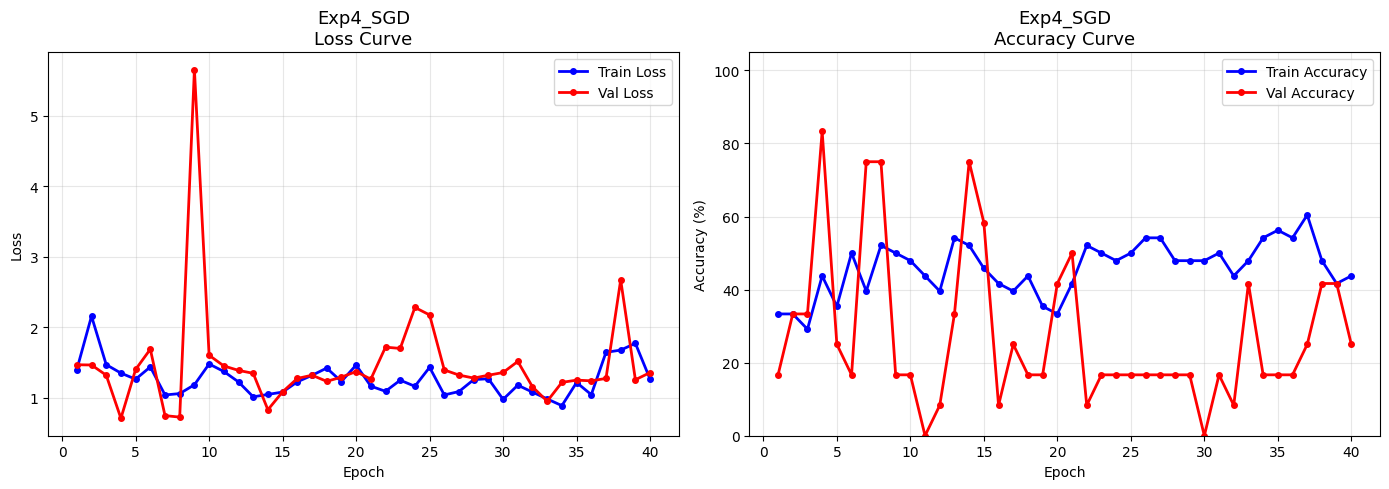

Plot saved as Exp4_SGD.png

EXPERIMENT 5: Low Learning Rate

  Experiment: Exp5 Low LR (lr=0.00001)
Epoch [  1/40] Train Loss: 1.4160 | Train Acc: 29.2% | Val Loss: 1.4041 | Val Acc: 0.0%
Epoch [  5/40] Train Loss: 1.2595 | Train Acc: 47.9% | Val Loss: 1.4682 | Val Acc: 16.7%
Epoch [ 10/40] Train Loss: 1.0689 | Train Acc: 68.8% | Val Loss: 1.3529 | Val Acc: 16.7%
Epoch [ 15/40] Train Loss: 0.9681 | Train Acc: 68.8% | Val Loss: 1.2879 | Val Acc: 16.7%
Epoch [ 20/40] Train Loss: 0.7193 | Train Acc: 85.4% | Val Loss: 1.1769 | Val Acc: 33.3%
Epoch [ 25/40] Train Loss: 0.6191 | Train Acc: 93.8% | Val Loss: 1.1355 | Val Acc: 33.3%
Epoch [ 30/40] Train Loss: 0.5730 | Train Acc: 91.7% | Val Loss: 1.0742 | Val Acc: 33.3%
Epoch [ 35/40] Train Loss: 0.4834 | Train Acc: 93.8% | Val Loss: 0.9578 | Val Acc: 41.7%
Epoch [ 40/40] Train Loss: 0.3866 | Train Acc: 91.7% | Val Loss: 0.9390 | Val Acc: 41.7%

Final Results:
  Best Train Acc: 93.8%
  Best Val Acc:   50.0%


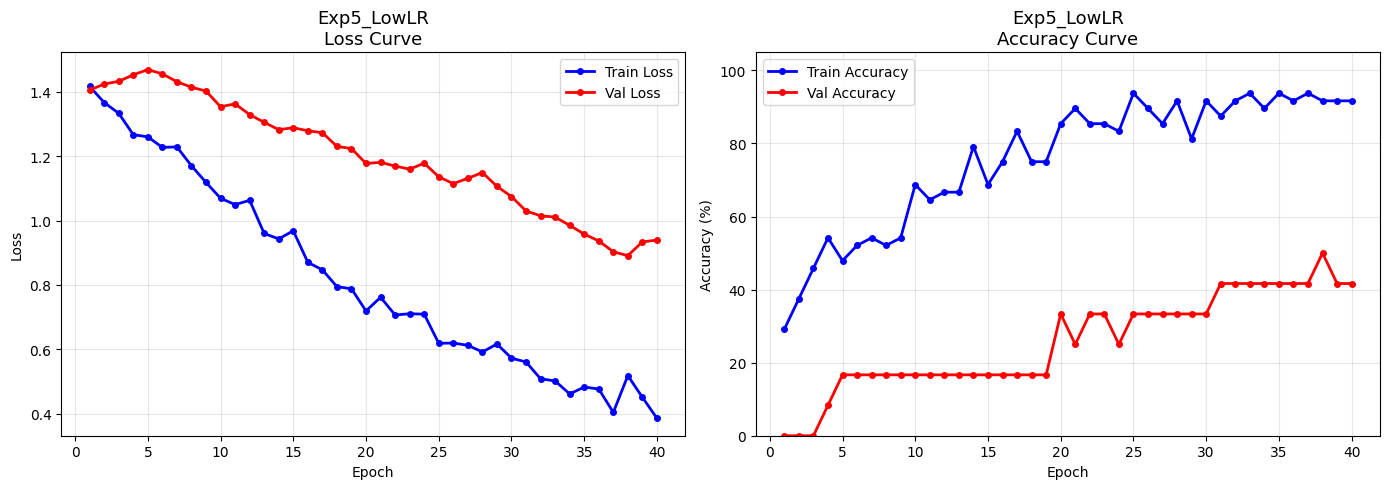

Plot saved as Exp5_LowLR.png


In [ ]:
NUM_EPOCHS = 40
all_histories = {}


# EXPERIMENT 1: Baseline (good settings)

print("\nEXPERIMENT 1: Baseline")
model1 = FruitClassifier(num_classes=4, dropout_rate=0.5).to(device)
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

h1 = train_model(model1, train_loader, val_loader,
                 criterion, optimizer1, NUM_EPOCHS,
                 "Exp1 Baseline (Adam lr=0.001)")
all_histories['Baseline'] = h1
plot_experiment(h1, "Exp1_Baseline")



# EXPERIMENT 2: Very High Learning Rate

print("\nEXPERIMENT 2: High Learning Rate (Unstable)")
model2 = FruitClassifier(num_classes=4, dropout_rate=0.5).to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=0.1)
# lr=0.1 is 100 times larger than baseline
# steps are too big, model overshoots the minimum

h2 = train_model(model2, train_loader, val_loader,
                 criterion, optimizer2, NUM_EPOCHS,
                 "Exp2 High LR (lr=0.1) - Unstable")
all_histories['High LR'] = h2
plot_experiment(h2, "Exp2_HighLR_Unstable")



# EXPERIMENT 3: No Dropout

print("\nEXPERIMENT 3: No Dropout (Overfitting)")
model3 = FruitClassifier(num_classes=4, dropout_rate=0.0).to(device)
# dropout_rate=0.0 means model will memorize training data

optimizer3 = optim.Adam(model3.parameters(), lr=0.001)

h3 = train_model(model3, train_loader, val_loader,
                 criterion, optimizer3, NUM_EPOCHS,
                 "Exp3 No Dropout - Overfitting")
all_histories['No Dropout'] = h3
plot_experiment(h3, "Exp3_NoDropout_Overfitting")


# EXPERIMENT 4: SGD Optimizer

print("\nEXPERIMENT 4: SGD Optimizer")
model4 = FruitClassifier(num_classes=4, dropout_rate=0.5).to(device)
optimizer4 = optim.SGD(model4.parameters(), lr=0.01, momentum=0.9)
# SGD = Stochastic Gradient Descent
# older optimizer, needs momentum to work well
# usually slower than Adam

h4 = train_model(model4, train_loader, val_loader,
                 criterion, optimizer4, NUM_EPOCHS,
                 "Exp4 SGD Optimizer")
all_histories['SGD'] = h4
plot_experiment(h4, "Exp4_SGD")



# EXPERIMENT 5: Very Low Learning Rate

print("\nEXPERIMENT 5: Low Learning Rate")
model5 = FruitClassifier(num_classes=4, dropout_rate=0.5).to(device)
optimizer5 = optim.Adam(model5.parameters(), lr=0.00001)
# lr=0.00001 is 100 times smaller than baseline
# steps are tiny, model learns very slowly

h5 = train_model(model5, train_loader, val_loader,
                 criterion, optimizer5, NUM_EPOCHS,
                 "Exp5 Low LR (lr=0.00001)")
all_histories['Low LR'] = h5
plot_experiment(h5, "Exp5_LowLR")

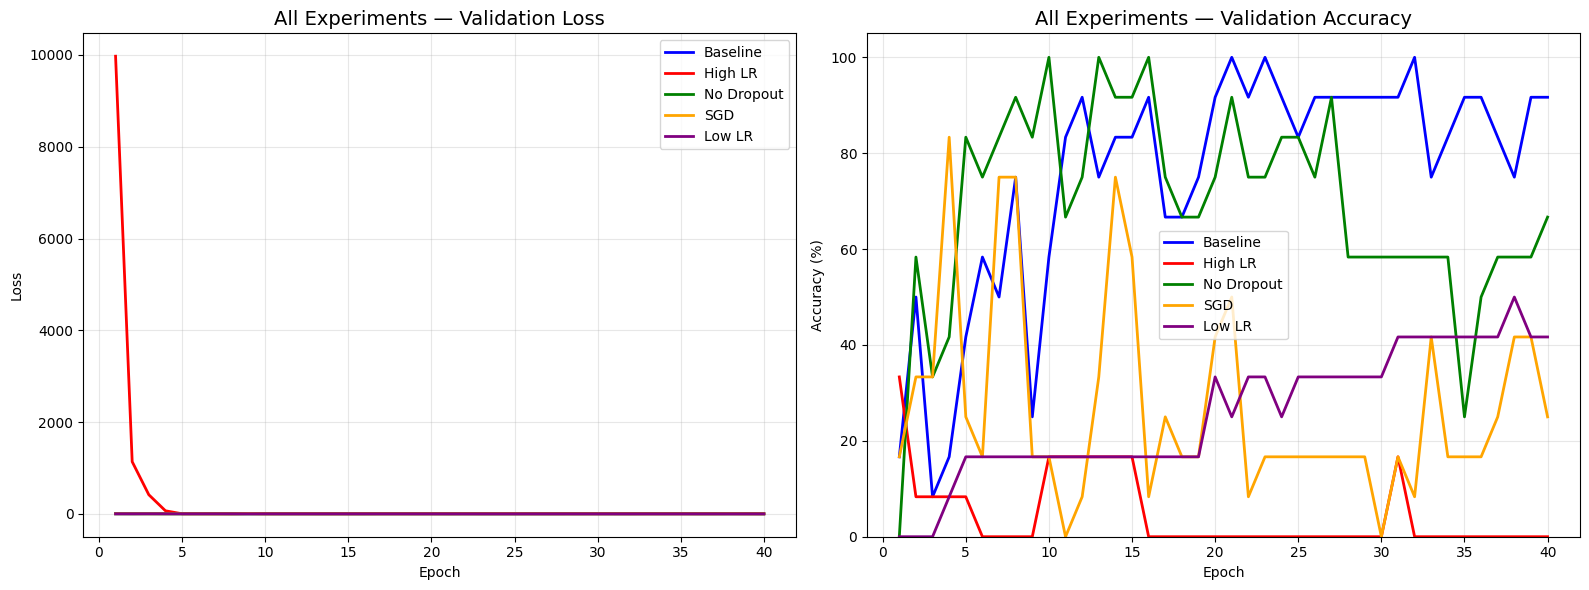

Comparison plot saved!


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
epochs = range(1, NUM_EPOCHS + 1)

colors = {
    'Baseline':   'blue',
    'High LR':    'red',
    'No Dropout': 'green',
    'SGD':        'orange',
    'Low LR':     'purple'
}

for name, history in all_histories.items():
    ax1.plot(epochs, history['val_loss'],
             label=name, color=colors[name], linewidth=2)
    ax2.plot(epochs, history['val_acc'],
             label=name, color=colors[name], linewidth=2)

ax1.set_title('All Experiments — Validation Loss', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title('All Experiments — Validation Accuracy', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 105])

plt.tight_layout()
plt.savefig('all_experiments_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison plot saved!")

SUMMARY TABLE

In [ ]:
print("\n" )
print(f"{'EXPERIMENT SUMMARY':^65}")
print("="*65)
print(f"{'Experiment':<20} {'Best Train Acc':>15} {'Best Val Acc':>13} {'Final Val Loss':>15}")

for name, history in all_histories.items():
    best_train = max(history['train_acc'])
    best_val = max(history['val_acc'])
    final_loss = history['val_loss'][-1]
    print(f"{name:<20} {best_train:>14.1f}% {best_val:>12.1f}% {final_loss:>15.4f}")

print("="*65)



                       EXPERIMENT SUMMARY                        
Experiment            Best Train Acc  Best Val Acc  Final Val Loss
Baseline                       97.9%        100.0%          0.1983
High LR                        45.8%         33.3%          1.5230
No Dropout                    100.0%        100.0%          0.4997
SGD                            60.4%         83.3%          1.3576
Low LR                         93.8%         50.0%          0.9390
